# Clasificación de Flores Iris con Random Forest

Este notebook implementa un pipeline completo de **aprendizaje automático supervisado** para clasificar flores del dataset `iris` de scikit-learn en tres especies: setosa, versicolor y virginica.

# Comprueba el entorno de ejecución
Usando `!` como prefijo, puedes ejecutar comandos de terminal directamente desde el notebook. Esto es útil para verificar que tienes las bibliotecas necesarias instaladas.

In [1]:
!python3 --version
!python3 -m pip list

Python 3.10.20
Package                   Version     Build
------------------------- ----------- -----
accelerate                1.13.0
annotated-doc             0.0.4
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.5
click                     8.3.1
comm                      0.2.3
contourpy                 1.3.2
cuda-bindings             12.9.4
cuda-pathfinder           1.4.2
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
exceptiongroup            1.3.1
executing                 2.2.1
fastjsonschema            2.21.2
filelock          

# Importa las bibliotecas necesarias

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Carga el dataset iris
El dataset `iris` contiene mediciones de longitud y anchura de sépalos y pétalos de flores. Cada muestra está etiquetada con la especie correspondiente.

In [3]:
iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Número de muestras:", X.shape[0])
print("Número de features:", X.shape[1])
print("Nombres de variables:", feature_names)
print("Clases:", list(target_names))

Número de muestras: 150
Número de features: 4
Nombres de variables: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Clases: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


# Visualiza las especies en dos variables
Representamos la longitud del sépalo frente a la longitud del pétalo para observar cómo se separan las clases.

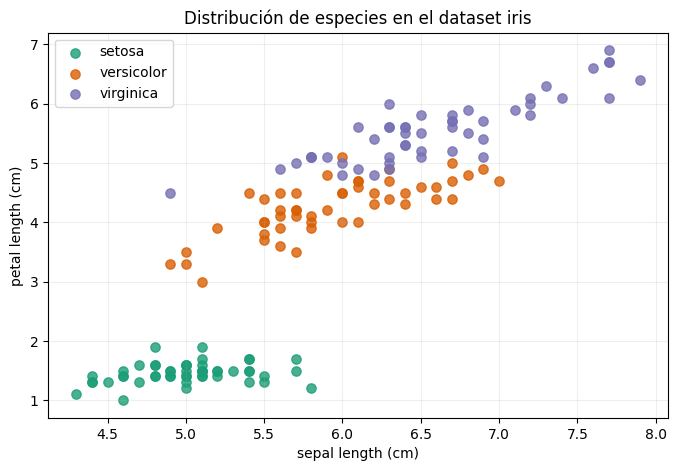

In [4]:
colors = ["#1b9e77", "#d95f02", "#7570b3"]

plt.figure(figsize=(8, 5))
for target, color, name in zip(range(len(target_names)), colors, target_names):
    subset = y == target
    plt.scatter(X[subset, 0], X[subset, 2], label=name, color=color, s=45, alpha=0.8)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[2])
plt.title("Distribución de especies en el dataset iris")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Prepara los datos para el entrenamiento
Dividimos los datos en entrenamiento y prueba para medir el rendimiento del modelo sobre observaciones no vistas.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Entrena un modelo de Random Forest
Random Forest combina múltiples árboles de decisión para obtener una predicción robusta sobre datos tabulares.

In [6]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Valida el modelo
Calculamos la accuracy y un informe de clasificación para revisar el comportamiento del modelo por especie.

In [7]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)
print()
print(classification_report(y_test, predictions, target_names=target_names))

Accuracy: 0.9

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



# Muestra una observación bien clasificada con su predicción
En lugar de imágenes, aquí inspeccionamos los valores de las variables de una flor que el modelo clasificó correctamente.

Clase real: setosa
Predicción: setosa

sepal length (cm): 4.4
sepal width (cm): 3.0
petal length (cm): 1.3
petal width (cm): 0.2


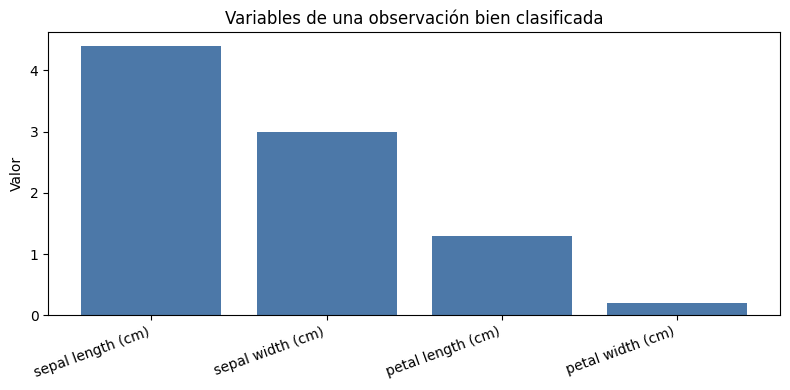

In [8]:
correct_idx = next(
    (i for i, (real, pred) in enumerate(zip(y_test, predictions)) if real == pred),
    None,
)

if correct_idx is not None:
    print("Clase real:", target_names[y_test[correct_idx]])
    print("Predicción:", target_names[predictions[correct_idx]])
    print()

    for name, value in zip(feature_names, X_test[correct_idx]):
        print(f"{name}: {value:.1f}")

    plt.figure(figsize=(8, 4))
    plt.bar(feature_names, X_test[correct_idx], color="#4c78a8")
    plt.title("Variables de una observación bien clasificada")
    plt.ylabel("Valor")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

# Muestra los errores de clasificación
Usamos una matriz de confusión y listamos algunos errores para entender mejor dónde se equivoca el modelo.

Número de errores: 3


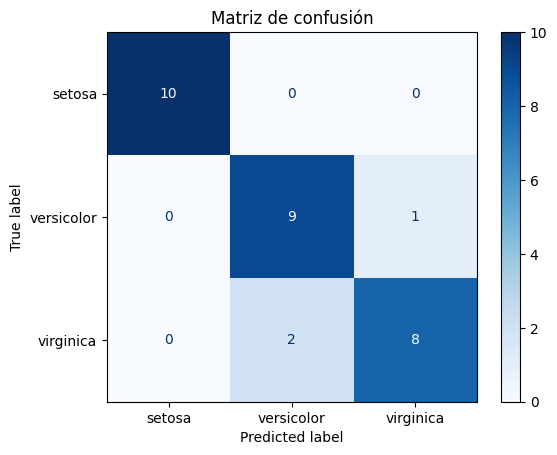


Primeros errores:
Real: virginica | Predicción: versicolor | sepal length (cm)=6.0, sepal width (cm)=3.0, petal length (cm)=4.8, petal width (cm)=1.8
Real: virginica | Predicción: versicolor | sepal length (cm)=6.1, sepal width (cm)=2.6, petal length (cm)=5.6, petal width (cm)=1.4
Real: versicolor | Predicción: virginica | sepal length (cm)=6.7, sepal width (cm)=3.0, petal length (cm)=5.0, petal width (cm)=1.7


In [9]:
errors = [i for i in range(len(y_test)) if y_test[i] != predictions[i]]

print("Número de errores:", len(errors))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=target_names,
    cmap="Blues",
    values_format="d",
)
plt.title("Matriz de confusión")
plt.show()

if errors:
    print()
    print("Primeros errores:")
    for idx in errors[:5]:
        feature_text = ", ".join(
            f"{name}={value:.1f}" for name, value in zip(feature_names, X_test[idx])
        )
        print(
            f"Real: {target_names[y_test[idx]]} | Predicción: {target_names[predictions[idx]]} | {feature_text}"
        )
else:
    print("No hubo errores de clasificación en el conjunto de prueba.")